# Entrenamiento de MLP para 4 gestos con IdeaBoard

Tomás de Camino Beck, Ph.D.   
Universidad CENFOTEC  

Este notebook entrena un perceptrón multicapa para reconocer 4 clases usando datos del acelerómetro. Es un ejemplo trivial, que tiene el fin solamente de mostrar como funciona el proceso de entrnamiento de un perceptrón. Las 4 clases son:

| Clase | Acción | Descripción |
|---|---|---|
| 0 | plano | La placa está horizontal, con gravedad principalmente en Z |
| 1 | arriba | Movimiento hacia arriba |
| 2 | izquierda | Movimiento hacia la izquierda |
| 3 | derecha | Movimiento hacia la derecha |

El modelo exportado queda en el archivo:

`gesture_model.nn`

Ese archivo se copia al ESP32 y luego se carga con:

```python
mlp = FastMLP([18, 12, 4])
mlp.load("gesture_model.nn")
```


## 1. Importar librerías

Usamos NumPy porque en Google Colab sí podemos entrenar con operaciones vectorizadas. Luego exportamos los pesos en un formato simple de texto compatible con CircuitPython.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
from google.colab import files


## 2. Clase FastMLP compatible con ESP32

Esta clase replica la lógica del MLP que luego se usa en el ESP32, pero usando NumPy completo para entrenar más rápido en Colab.


In [2]:
class FastMLP:

    def __init__(self, layers, learning_rate=0.05, seed=42):

        np.random.seed(seed)

        self.layers = layers
        self.learning_rate = learning_rate

        self.weights = []
        self.biases = []

        for i in range(len(layers) - 1):

            rows = layers[i + 1]
            cols = layers[i]

            W = np.random.uniform(-1.0, 1.0, (rows, cols))
            b = np.random.uniform(-1.0, 1.0, rows)

            self.weights.append(W)
            self.biases.append(b)

    def sigmoid(self, x):

        x = np.clip(x, -20, 20)

        return 1.0 / (1.0 + np.exp(-x))

    def forward(self, x):

        activations = [x]

        a = x

        for W, b in zip(self.weights, self.biases):

            z = np.dot(W, a) + b
            a = self.sigmoid(z)

            activations.append(a)

        return activations

    def predict(self, inputs):

        x = np.array(inputs, dtype=float)

        return self.forward(x)[-1]

    def train(self, inputs, targets):

        x = np.array(inputs, dtype=float)
        y = np.array(targets, dtype=float)

        activations = self.forward(x)

        deltas = [None] * len(self.weights)

        output = activations[-1]
        error = y - output

        deltas[-1] = error * output * (1.0 - output)

        for layer in range(len(self.weights) - 2, -1, -1):

            propagated = np.dot(
                self.weights[layer + 1].T,
                deltas[layer + 1]
            )

            a = activations[layer + 1]

            deltas[layer] = propagated * a * (1.0 - a)

        for layer in range(len(self.weights)):

            self.weights[layer] += (
                self.learning_rate *
                np.outer(deltas[layer], activations[layer])
            )

            self.biases[layer] += (
                self.learning_rate *
                deltas[layer]
            )

    def argmax(self, vector):

        return int(np.argmax(vector))

    def save(self, filename):

        with open(filename, "w") as f:

            f.write(str(len(self.weights)))
            f.write("\n")

            for W in self.weights:
                f.write(str(W.tolist()))
                f.write("\n")

            f.write("BIAS\n")

            for b in self.biases:
                f.write(str(b.tolist()))
                f.write("\n")


## 3. Formato de entrada

Cada gesto se representa con 6 muestras consecutivas del acelerómetro.

Cada muestra tiene:

- `ax`
- `ay`
- `az`

Entonces cada vector de entrada tiene:

```text
6 muestras × 3 ejes = 18 valores
```

La arquitectura usada será:

```text
18 entradas → 12 neuronas ocultas → 4 salidas
```


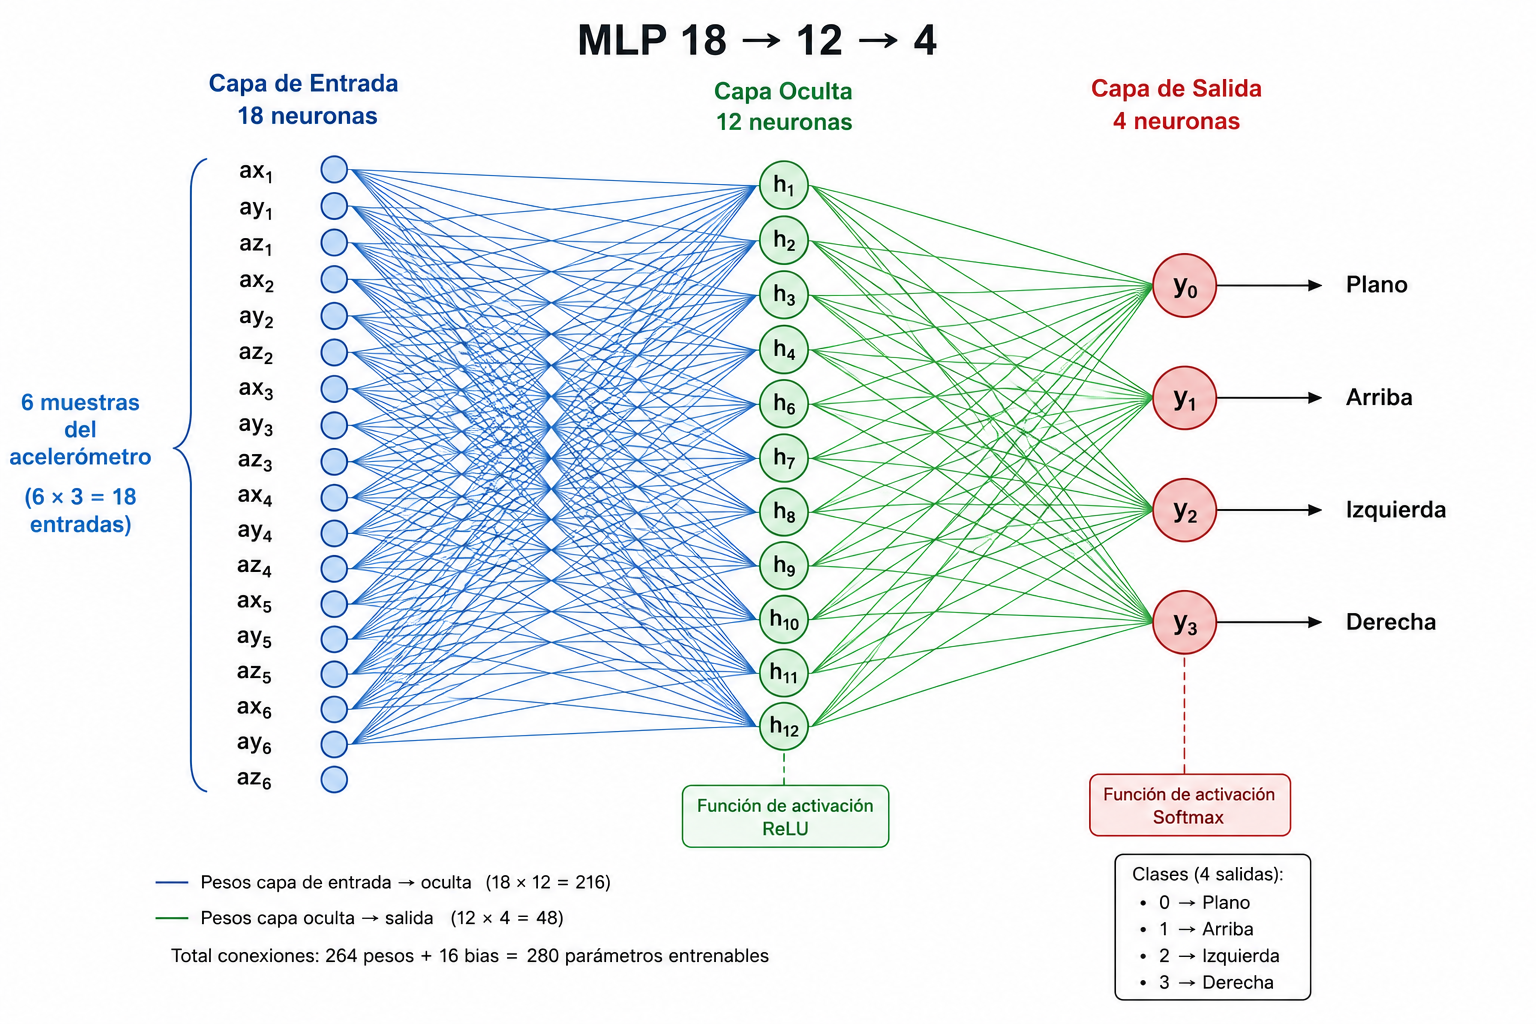

## 4. Generar datos sintéticos iniciales

Estos datos sirven para probar el flujo completo. Para un proyecto real, después conviene reemplazarlos por datos capturados desde la IdeaBoard en CSV.

La clase **plano** se modela como valores cercanos a:

```text
ax ≈ 0
ay ≈ 0
az ≈ 9.8
```

Luego se normaliza dividiendo entre 10 para que los valores estén aproximadamente entre -1 y 1.


In [3]:
N_SAMPLES_PER_CLASS = 120
WINDOW_SIZE = 6

def make_window(base_values, noise=0.05):
    """Crea una ventana de 6 muestras ax, ay, az normalizadas."""

    values = []

    for _ in range(WINDOW_SIZE):

        ax = base_values[0] + np.random.normal(0, noise)
        ay = base_values[1] + np.random.normal(0, noise)
        az = base_values[2] + np.random.normal(0, noise)

        values.extend([ax, ay, az])

    return values


X = []
Y = []

class_names = [
    "plano",
    "arriba",
    "izquierda",
    "derecha"
]

bases = {
    0: [0.0, 0.0, 0.98],
    1: [0.0, 0.85, 0.70],
    2: [-0.85, 0.0, 0.70],
    3: [0.85, 0.0, 0.70]
}

for class_id in range(4):

    for _ in range(N_SAMPLES_PER_CLASS):

        X.append(
            make_window(
                bases[class_id],
                noise=0.08
            )
        )

        target = [0, 0, 0, 0]
        target[class_id] = 1

        Y.append(target)

X = np.array(X, dtype=float)
Y = np.array(Y, dtype=float)

print("X shape:", X.shape)
print("Y shape:", Y.shape)


X shape: (480, 18)
Y shape: (480, 4)


## 5. Mezclar y dividir los datos

Usamos 80% para entrenamiento y 20% para prueba.


In [4]:
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
Y = Y[indices]

split = int(0.8 * len(X))

X_train = X[:split]
Y_train = Y[:split]

X_test = X[split:]
Y_test = Y[split:]

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)


Entrenamiento: (384, 18)
Prueba: (96, 18)


## 6. Crear y entrenar el MLP

La salida tiene 4 neuronas, una por clase.


In [6]:
mlp = FastMLP(
    [18, 12, 4],
    learning_rate=0.08,
    seed=42
)

epochs = 500

history = []

for epoch in range(epochs):

    for x, y in zip(X_train, Y_train):
        mlp.train(x, y)

    if epoch % 100 == 0:

        correct = 0

        for x, y in zip(X_test, Y_test):

            pred = mlp.predict(x)

            if mlp.argmax(pred) == int(np.argmax(y)):
                correct += 1

        accuracy = correct / len(X_test)

        history.append(accuracy)

        print("Epoch:", epoch, "Accuracy:", round(accuracy, 4))


Epoch: 0 Accuracy: 0.8333
Epoch: 100 Accuracy: 1.0
Epoch: 200 Accuracy: 1.0
Epoch: 300 Accuracy: 1.0
Epoch: 400 Accuracy: 1.0


## 7. Graficar la evolución de precisión

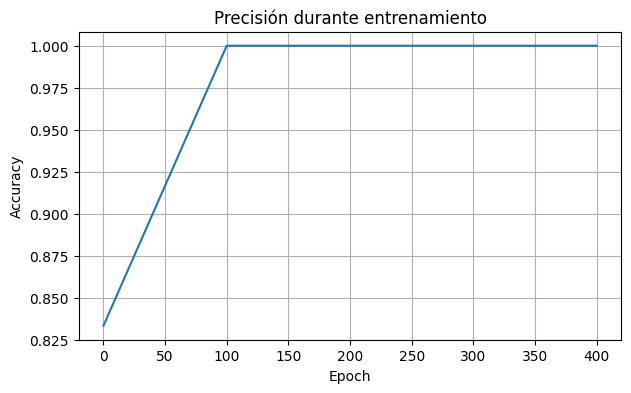

In [7]:
plt.figure(figsize=(7,4))
plt.plot(np.arange(len(history)) * 100, history)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Precisión durante entrenamiento")
plt.grid(True)
plt.show()


## 8. Evaluación final

In [8]:
correct = 0
confusion = np.zeros((4, 4), dtype=int)

for x, y in zip(X_test, Y_test):

    pred = mlp.predict(x)

    predicted_class = mlp.argmax(pred)
    true_class = int(np.argmax(y))

    confusion[true_class, predicted_class] += 1

    if predicted_class == true_class:
        correct += 1

accuracy = correct / len(X_test)

print("Accuracy final:", accuracy)
print()
print("Matriz de confusión")
print(confusion)

print()
print("Filas = clase real")
print("Columnas = clase predicha")
print(class_names)


Accuracy final: 1.0

Matriz de confusión
[[21  0  0  0]
 [ 0 31  0  0]
 [ 0  0 23  0]
 [ 0  0  0 21]]

Filas = clase real
Columnas = clase predicha
['plano', 'arriba', 'izquierda', 'derecha']


## 9. Probar muestras individuales

In [9]:
def test_example(vector):

    pred = mlp.predict(vector)

    class_id = mlp.argmax(pred)

    print("Salida:", np.round(pred, 3))
    print("Clase:", class_id, "-", class_names[class_id])


print("Prueba con placa plana")
test_example(make_window([0.0, 0.0, 0.98], noise=0.02))

print()
print("Prueba con gesto arriba")
test_example(make_window([0.0, 0.85, 0.70], noise=0.02))

print()
print("Prueba con gesto izquierda")
test_example(make_window([-0.85, 0.0, 0.70], noise=0.02))

print()
print("Prueba con gesto derecha")
test_example(make_window([0.85, 0.0, 0.70], noise=0.02))


Prueba con placa plana
Salida: [0.99  0.002 0.008 0.006]
Clase: 0 - plano

Prueba con gesto arriba
Salida: [0.004 0.991 0.005 0.006]
Clase: 1 - arriba

Prueba con gesto izquierda
Salida: [0.008 0.007 0.993 0.001]
Clase: 2 - izquierda

Prueba con gesto derecha
Salida: [0.008 0.007 0.    0.992]
Clase: 3 - derecha


## 10. Guardar modelo para ESP32

Este archivo es el que se debe copiar al ESP32 junto con `mlp.py`.


In [11]:
MODEL_FILE = "gesture_model.nn"

mlp.save(MODEL_FILE)

print("Modelo guardado como:", MODEL_FILE)


Modelo guardado como: gesture_model.nn


## 11. Descargar modelo entrenado

In [12]:
files.download(MODEL_FILE)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Opcional: entrenar con datos reales desde CSV

Cuando capturés datos reales con la IdeaBoard, podés usar esta sección.

El CSV recomendado debe tener columnas:

```text
ax1,ay1,az1,ax2,ay2,az2,...,ax6,ay6,az6,label
```

Donde `label` debe ser:

| label | clase |
|---|---|
| 0 | plano |
| 1 | arriba |
| 2 | izquierda |
| 3 | derecha |

Los valores de acelerómetro deberían estar normalizados, por ejemplo dividiendo entre 10 en el ESP32.


In [ ]:
# Ejecutar esta celda solo si ya tenés un CSV real.

uploaded = files.upload()

csv_filename = list(uploaded.keys())[0]

X_real = []
Y_real = []

with open(csv_filename, "r") as f:

    reader = csv.reader(f)

    header = next(reader)

    for row in reader:

        values = [float(v) for v in row[:-1]]
        label = int(row[-1])

        target = [0, 0, 0, 0]
        target[label] = 1

        X_real.append(values)
        Y_real.append(target)

X_real = np.array(X_real, dtype=float)
Y_real = np.array(Y_real, dtype=float)

print("Datos reales cargados:", X_real.shape, Y_real.shape)


## Entrenar con CSV real

Ejecutá esta sección solo después de cargar el CSV real.


In [ ]:
# Descomentar para entrenar con datos reales.

# indices = np.arange(len(X_real))
# np.random.shuffle(indices)

# X_real = X_real[indices]
# Y_real = Y_real[indices]

# split = int(0.8 * len(X_real))

# X_train = X_real[:split]
# Y_train = Y_real[:split]

# X_test = X_real[split:]
# Y_test = Y_real[split:]

# mlp = FastMLP(
#     [18, 12, 4],
#     learning_rate=0.08,
#     seed=42
# )

# for epoch in range(3000):

#     for x, y in zip(X_train, Y_train):
#         mlp.train(x, y)

#     if epoch % 250 == 0:
#         correct = 0

#         for x, y in zip(X_test, Y_test):
#             pred = mlp.predict(x)

#             if mlp.argmax(pred) == int(np.argmax(y)):
#                 correct += 1

#         print("Epoch:", epoch, "Accuracy:", correct / len(X_test))

# mlp.save("gesture_model_4clases_real.txt")
# files.download("gesture_model_4clases_real.txt")


# Código esperado en ESP32

Después de copiar el modelo al ESP32:

```python
from ideasense import IdeaSense
from mlp import FastMLP

sense = IdeaSense()

mlp = FastMLP([18, 12, 4])
mlp.load("gesture_model_4clases.txt")
```

Las clases quedan así:

```python
0 = plano
1 = arriba
2 = izquierda
3 = derecha
```


## Porque MLP y no simplemente `if`

Las reglas `if` son una forma de conocimiento explícito. El programador observa el comportamiento, formula las condiciones y las escribe manualmente:

```python
if az > 8:
    clase = "plano"

elif ay > 5:
    clase = "arriba"

elif ax < -5:
    clase = "izquierda"

elif ax > 5:
    clase = "derecha"
```

El sistema no aprende nada. Si mañana querés reconocer un gesto nuevo, tenés que modificar el código.

En cambio, con el MLP la lógica está distribuida en los pesos de la red. El programador no define las reglas, sino que proporciona ejemplos:

```text
ejemplo → etiqueta
ejemplo → etiqueta
ejemplo → etiqueta
...
```

y el algoritmo construye internamente una aproximación a la función de clasificación.

Este experimento  interesante en clase no es comparar precisión, porque para estas cuatro clases simples probablemente los `if` ganen. Lo interesante es comparar **adaptabilidad**.

Podrías hacer algo como:

| Experimento                            | If          | MLP        |
| -------------------------------------- | ----------- | ---------- |
| Plano                                  | Fácil       | Fácil      |
| Izquierda                              | Fácil       | Fácil      |
| Derecha                                | Fácil       | Fácil      |
| Arriba                                 | Fácil       | Fácil      |
| Movimiento circular                    | Difícil     | Entrenable |
| Sacudir                                | Difícil     | Entrenable |
| Firma personal de un estudiante        | Muy difícil | Entrenable |
| Nuevo gesto inventado durante la clase | Reprogramar | Reentrenar |

Eso permite discutir varias ideas fundamentales de IA:

* Programación explícita versus aprendizaje.
* Generalización.
* Separación entre algoritmo y conocimiento.
* Datos como mecanismo de programación.
* Transferencia del diseño desde el programador hacia el conjunto de entrenamiento.

Incluso se puede hacer un ejercicio muy interesante:

1. Primero implementar los `if`.
2. Mostrar que funcionan perfectamente.
3. Pedir a los estudiantes que inventen un gesto nuevo.
4. Preguntar cuánto código habría que modificar.
5. Recolectar 20 ejemplos del nuevo gesto.
6. Reentrenar el MLP.
7. Mostrar que el programa del ESP32 no cambió ni una línea.

Dicho de otro modo:

> Con los `if`, modificamos el código para cambiar el comportamiento.
>
> Con el MLP, modificamos los datos para cambiar el comportamiento.

Esa diferencia captura bastante bien la transición desde la programación clásica hacia los sistemas de aprendizaje.
